In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"richavasudeva","key":"431836916cac4626117dc00e2b6adc40"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list -s pneumonia

ref                                                            title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
paultimothymooney/chest-xray-pneumonia                         Chest X-Ray Images (Pneumonia)                       2463365435  2018-03-24 19:41:59.603000         628463       7561  0.75             
pcbreviglieri/pneumonia-xray-images                            Pneumonia X-Ray Images                               1225740412  2020-05-18 14:32:09.660000          12590        101  0.9375           
iamtapendu/rsna-pneumonia-processed-dataset                    RSNA Pneumonia Processed Dataset                    11748997093  2024-11-10 17:28:20.063000           4456         33  1                


In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:12<00:00, 18.6MB/s]



In [5]:
!unzip -q chest-xray-pneumonia.zip

In [6]:
!ls

chest_xray  chest-xray-pneumonia.zip  kaggle.json  sample_data


In [7]:
!find /content -maxdepth 2 -type d | grep chest

/content/chest_xray
/content/chest_xray/__MACOSX
/content/chest_xray/train
/content/chest_xray/val
/content/chest_xray/test
/content/chest_xray/chest_xray


In [8]:
dataset_path = "/content/chest_xray"

In [9]:
!ls /content/chest_xray

chest_xray  __MACOSX  test  train  val


In [10]:
import os

for split in ['train','val','test']:
    print(f"\n{split.upper()}")

    split_path = os.path.join('/content/chest_xray', split)

    for cls in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(cls, ":", count)


TRAIN
PNEUMONIA : 3875
NORMAL : 1341

VAL
PNEUMONIA : 8
NORMAL : 8

TEST
PNEUMONIA : 390
NORMAL : 234


In [12]:
train_dir = "/content/chest_xray/train"
val_dir = "/content/chest_xray/val"
test_dir = "/content/chest_xray/test"

print(train_dir)
print(val_dir)
print(test_dir)

/content/chest_xray/train
/content/chest_xray/val
/content/chest_xray/test


In [13]:
# creating image generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


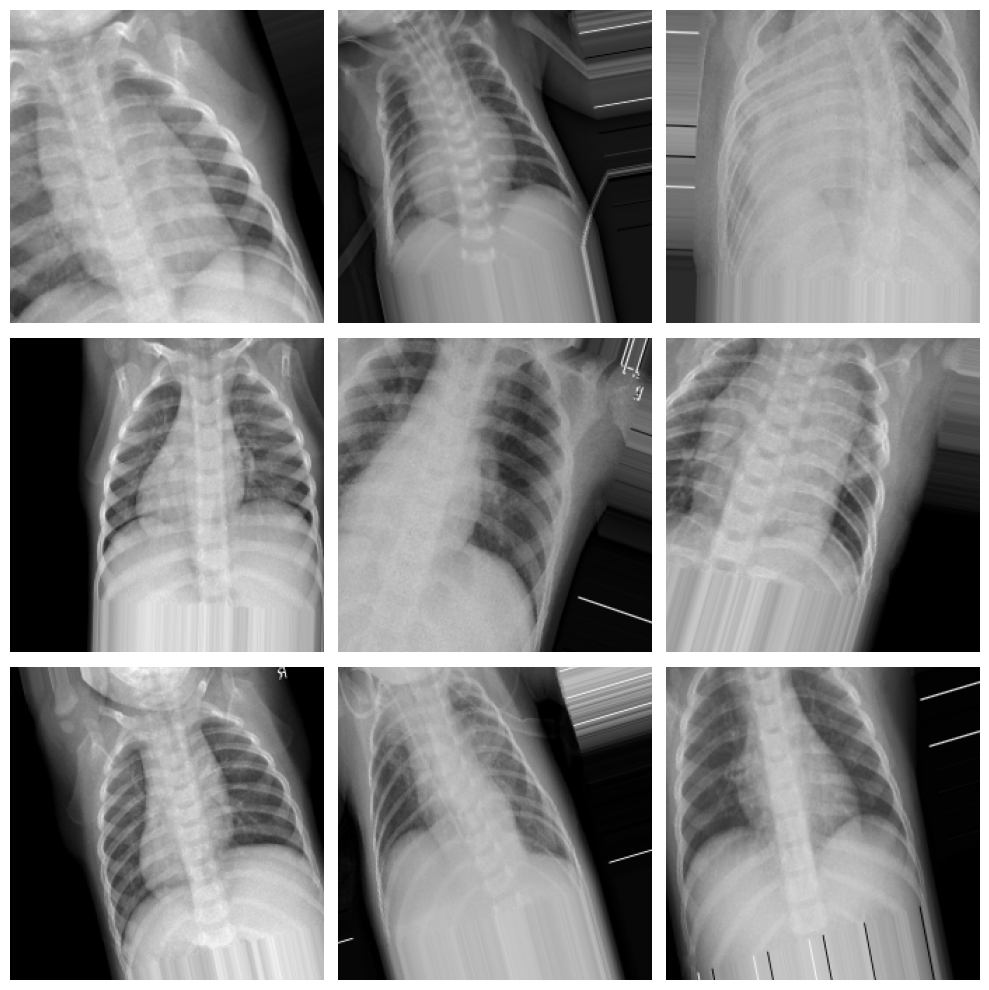

In [14]:
# visulising augmented images
images, labels = next(train_generator)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
# building transfer learning model mobilenet
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [16]:
#loading pretrained model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
# custom classification head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# compiling model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
# trainig model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 711ms/step - accuracy: 0.8215 - loss: 0.4058 - val_accuracy: 0.6875 - val_loss: 0.4175
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 623ms/step - accuracy: 0.9132 - loss: 0.2121 - val_accuracy: 0.8750 - val_loss: 0.3483
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 618ms/step - accuracy: 0.9189 - loss: 0.1945 - val_accuracy: 0.8750 - val_loss: 0.3207
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.9252 - loss: 0.1763 - val_accuracy: 0.8125 - val_loss: 0.3495
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 619ms/step - accuracy: 0.9243 - loss: 0.1783 - val_accuracy: 0.8125 - val_loss: 0.3490


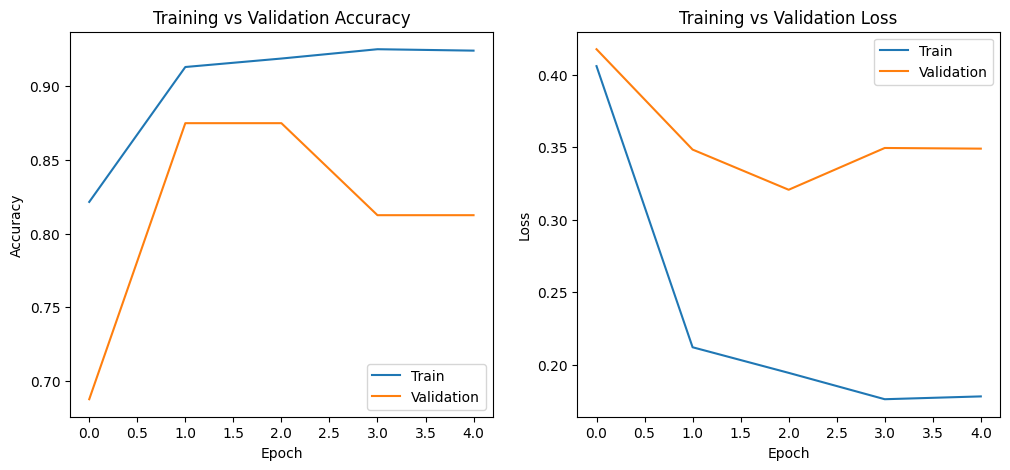

In [21]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

pred_prob = model.predict(test_generator)

pred_classes = (pred_prob > 0.5).astype(int)

true_classes = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 745ms/step


In [23]:
# precesion
precision = precision_score(
    true_classes,
    pred_classes
)

print("Precision:", precision)

Precision: 0.8538812785388128


In [24]:
# recall
precision = precision_score(
    true_classes,
    pred_classes
)

print("Precision:", precision)

Precision: 0.8538812785388128


In [25]:
# F1 Score
f1 = f1_score(
    true_classes,
    pred_classes
)

print("F1 Score:", f1)

F1 Score: 0.9033816425120773


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [28]:
print(classification_report(
    true_classes,
    pred_classes,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.91      0.73      0.81       234
   PNEUMONIA       0.85      0.96      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.86       624
weighted avg       0.88      0.87      0.87       624



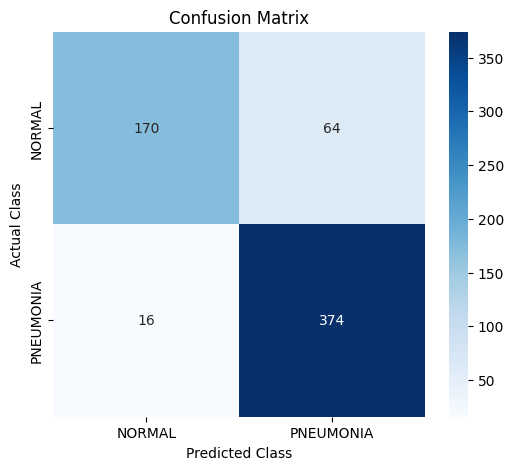

In [29]:
# confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


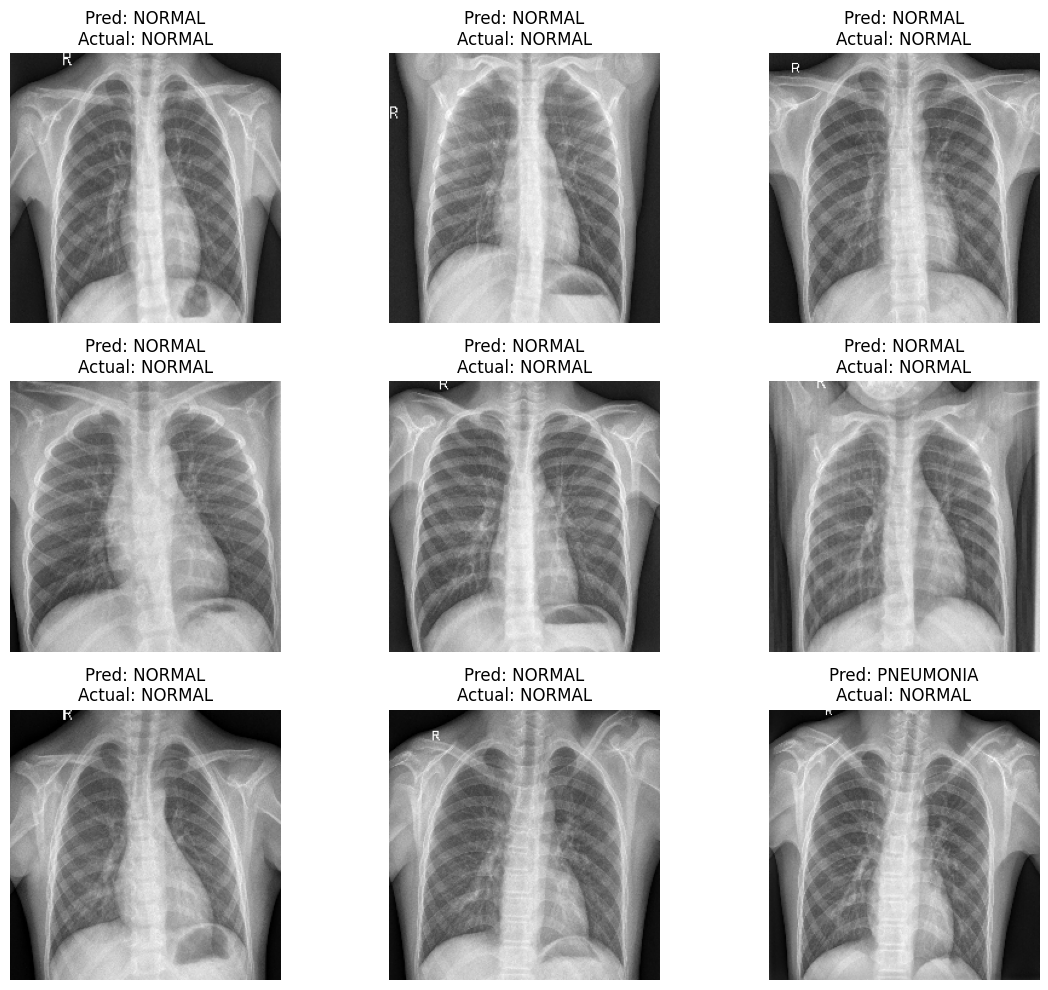

In [30]:
# visulaisation
import numpy as np
import matplotlib.pyplot as plt

test_generator.reset()

images, labels = next(test_generator)

preds = model.predict(images)

preds = (preds > 0.5).astype(int)

class_names = ['NORMAL','PNEUMONIA']

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred_label = class_names[preds[i][0]]

    true_label = class_names[int(labels[i])]

    plt.title(
        f"Pred: {pred_label}\nActual: {true_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()